<a href="https://colab.research.google.com/github/mwaniasam/formative1-working_with_time_series_data/blob/main/Pipeline_formative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1C: Model Training — Classical ML vs Deep Learning (LSTM)
**Dataset:** Hourly Energy Generation, Load & Price Data (Spain, 2015–2018)  
**Target Variable:** `price actual` — Hourly electricity market price (€/MWh)  

### Models Compared:
| # | Model | Type |
|---|-------|------|
| Exp 1 | Ridge Regression | Classical ML (Linear) |
| Exp 2 | Random Forest | Classical ML (Ensemble) |
| Exp 3 | LSTM (1 layer) | Deep Learning |
| Exp 4 | LSTM (2 layers, tuned) | Deep Learning (Best) |

---
## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Classical ML
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import json

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported!')

TensorFlow version: 2.19.0
All libraries imported!


---
## 2. Load & Preprocess Data

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
from google.colab import files
uploaded = files.upload()

Saving energy_dataset.csv to energy_dataset (1).csv


In [16]:
df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)
df.set_index('time', inplace=True)

# Drop fully null columns
all_null_cols = df.columns[df.isnull().all()].tolist()
df.drop(columns=all_null_cols, inplace=True)
print(f'Dropped fully null columns: {all_null_cols}')

# Forward fill small gaps
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f'Shape: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')
df.head(3)

Dropped fully null columns: ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
Shape: (35064, 26)
Missing values remaining: 0


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage consumption,...,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,863.0,...,49.0,196.0,0.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,920.0,...,50.0,195.0,0.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,1164.0,...,50.0,196.0,0.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48


---
## 3. Feature Engineering

In [17]:
# Time features
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['quarter']     = df.index.quarter
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)

# Lag features
# Price lags: 1h ago, 24h ago (same hour yesterday), 168h ago (same hour last week)
for lag in [1, 24, 168]:
    df[f'price_lag_{lag}h'] = df['price actual'].shift(lag)

# Load lags
for lag in [1, 24]:
    df[f'load_lag_{lag}h'] = df['total load actual'].shift(lag)

# Moving average features
# shift(1) ensures no data leakage — we only use past values
df['price_ma_24h']  = df['price actual'].shift(1).rolling(24).mean()
df['price_ma_168h'] = df['price actual'].shift(1).rolling(168).mean()
df['price_std_24h'] = df['price actual'].shift(1).rolling(24).std()
df['load_ma_24h']   = df['total load actual'].shift(1).rolling(24).mean()

# Drop NaN rows from lag/rolling
df.dropna(inplace=True)
print(f'Final shape after feature engineering: {df.shape}')

Final shape after feature engineering: (34896, 40)


---
## 4. Define Features & Target

In [18]:
TARGET   = 'price actual'
DROP_COLS = ['price day ahead']  # forward-looking — would cause data leakage

FEATURES = [col for col in df.columns if col != TARGET and col not in DROP_COLS]

X = df[FEATURES].values
y = df[TARGET].values

print(f'Number of features : {len(FEATURES)}')
print(f'Features           : {FEATURES}')
print(f'Total samples      : {len(X):,}')

Number of features : 38
Features           : ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'price_lag_1h', 'price_lag_24h', 'price_lag_168h', 'load_lag_1h', 'load_lag_24h', 'price_ma_24h', 'price_ma_168h', 'price_std_24h', 'load_ma_24h']
Total samples      : 34,896


---
## 5. Train / Test Split (Chronological — No Shuffle)

In [19]:
split_idx = int(len(X) * 0.8)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train,     y_test     = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates  = df.index[split_idx:]

print(f'Training : {len(X_train_raw):,} samples  |  {train_dates[0].date()} → {train_dates[-1].date()}')
print(f'Testing  : {len(X_test_raw):,} samples  |  {test_dates[0].date()} → {test_dates[-1].date()}')

Training : 27,916 samples  |  2015-01-07 → 2018-03-16
Testing  : 6,980 samples  |  2018-03-16 → 2018-12-31


---
## 6. Scaling
- **StandardScaler** for classical ML models
- **MinMaxScaler** for LSTM (neural networks prefer data in [0,1] range)

In [20]:
# For classical ML
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train_raw)
X_test_std  = std_scaler.transform(X_test_raw)

# For LSTM — scale features and target separately
mm_scaler_X = MinMaxScaler()
mm_scaler_y = MinMaxScaler()

X_train_mm = mm_scaler_X.fit_transform(X_train_raw)
X_test_mm  = mm_scaler_X.transform(X_test_raw)
y_train_mm = mm_scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_mm  = mm_scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Save scalers for Task 4
joblib.dump(std_scaler, 'scaler_standard.pkl')
joblib.dump(mm_scaler_X, 'scaler_minmax_X.pkl')
joblib.dump(mm_scaler_y, 'scaler_minmax_y.pkl')
print('Scalers saved.')

Scalers saved.


---
## 7. Evaluation Helper

In [21]:
results_log = []

def evaluate(name, y_true, y_pred, hyperparams='', notes=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    sep  = '=' * 55        # ← fix: define separator outside f-string
    print(f'\n{sep}')
    print(f' {name}')
    print(f'{sep}')
    print(f'  MAE  : {mae:.4f} €/MWh')
    print(f'  RMSE : {rmse:.4f} €/MWh')
    print(f'  R²   : {r2:.4f}')
    results_log.append({
        'Model': name,
        'Hyperparameters': hyperparams,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
        'Notes': notes
    })
    return y_pred

---
# CLASSICAL ML MODELS

## Experiment 1 — Ridge Regression
**Why:** Fast baseline. Applies L2 regularization to handle multicollinearity between energy features.

In [22]:
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid   = GridSearchCV(Ridge(), ridge_params, cv=5,
                            scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_std, y_train)

best_ridge    = ridge_grid.best_estimator_
best_alpha    = ridge_grid.best_params_['alpha']
y_pred_ridge  = best_ridge.predict(X_test_std)

print(f'Best alpha: {best_alpha}')
evaluate('Exp 1: Ridge Regression',
         y_test, y_pred_ridge,
         hyperparams=f'alpha={best_alpha}',
         notes='Regularized linear model — baseline')

joblib.dump(best_ridge, 'model_ridge.pkl')
print('Saved: model_ridge.pkl')

Best alpha: 10.0

 Exp 1: Ridge Regression
  MAE  : 1.6686 €/MWh
  RMSE : 2.3542 €/MWh
  R²   : 0.9579
Saved: model_ridge.pkl


## Experiment 2 — Random Forest
**Why:** Ensemble of decision trees, captures non-linear relationships and feature interactions that Ridge misses.

In [23]:
rf_params = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                       cv=3, scoring='neg_mean_squared_error',
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train_std, y_train)

best_rf   = rf_grid.best_estimator_
best_rf_p = rf_grid.best_params_
y_pred_rf = best_rf.predict(X_test_std)

print(f'Best params: {best_rf_p}')
evaluate('Exp 2: Random Forest',
         y_test, y_pred_rf,
         hyperparams=str(best_rf_p),
         notes='Ensemble — handles non-linearity')

joblib.dump(best_rf, 'model_random_forest.pkl')
print('Saved: model_random_forest.pkl')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

 Exp 2: Random Forest
  MAE  : 1.7759 €/MWh
  RMSE : 2.3647 €/MWh
  R²   : 0.9575
Saved: model_random_forest.pkl


---
# DEEP LEARNING — LSTM
LSTM (Long Short-Term Memory) is specifically designed for sequential/time-series data. Unlike classical ML models that treat each row independently, LSTM learns from sequences of past timesteps — making it naturally suited for energy price forecasting.

## Prepare Sequences for LSTM
LSTM expects 3D input: `(samples, timesteps, features)`  
We use a **lookback window of 24 hours** — the model sees the past 24 hours to predict the next hour.

In [24]:
LOOKBACK = 24  # use past 24 hours as input window

def create_sequences(X, y, lookback):
    """Convert flat arrays into overlapping sequences for LSTM."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Build sequences from MinMax-scaled data
X_seq_all = np.concatenate([X_train_mm, X_test_mm], axis=0)
y_seq_all = np.concatenate([y_train_mm, y_test_mm], axis=0)

X_seq, y_seq = create_sequences(X_seq_all, y_seq_all, LOOKBACK)

# Chronological split for sequences
seq_split = split_idx - LOOKBACK
X_seq_train, X_seq_test = X_seq[:seq_split], X_seq[seq_split:]
y_seq_train, y_seq_test = y_seq[:seq_split], y_seq[seq_split:]

# Get original-scale y_test for evaluation
y_test_lstm = y_test[LOOKBACK:]

print(f'LSTM input shape  : {X_seq_train.shape}  →  (samples, timesteps={LOOKBACK}, features={len(FEATURES)})')
print(f'LSTM train samples: {X_seq_train.shape[0]:,}')
print(f'LSTM test  samples: {X_seq_test.shape[0]:,}')

LSTM input shape  : (27892, 24, 38)  →  (samples, timesteps=24, features=38)
LSTM train samples: 27,892
LSTM test  samples: 6,980


## Experiment 3 — LSTM (Single Layer, Baseline)
**Architecture:** 1 LSTM layer (64 units) → Dense output  
**Why start simple:** Establish a DL baseline before adding complexity.

In [25]:
tf.random.set_seed(42)

def build_lstm_simple(input_shape, lstm_units=64, learning_rate=0.001):
    model = Sequential([
        LSTM(lstm_units, input_shape=input_shape, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

input_shape = (LOOKBACK, len(FEATURES))
lstm_simple = build_lstm_simple(input_shape, lstm_units=64, learning_rate=0.001)
lstm_simple.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history_simple = lstm_simple.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Predict & inverse transform
y_pred_lstm_simple_scaled = lstm_simple.predict(X_seq_test).flatten()
y_pred_lstm_simple = mm_scaler_y.inverse_transform(
    y_pred_lstm_simple_scaled.reshape(-1, 1)
).flatten()

# Fix: align y_test_lstm to match prediction length
y_test_lstm = y_test[-len(y_pred_lstm_simple):]

evaluate('Exp 3: LSTM (1 Layer, 64 units)',
         y_test_lstm, y_pred_lstm_simple,
         hyperparams='units=64, lr=0.001, dropout=0.2, lookback=24',
         notes='Baseline LSTM — single layer')

lstm_simple.save('model_lstm_simple.keras')
print('Saved: model_lstm_simple.keras')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,481 (111.25 KB)

 Trainable params: 28,481 (111.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0248 - mae: 0.1059 - val_loss: 0.0081 - val_mae: 0.0719
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0043 - mae: 0.0506 - val_loss: 0.0050 - val_mae: 0.0542
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0031 - mae: 0.0428 - val_loss: 0.0034 - val_mae: 0.0436
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0025 - mae: 0.0384 - val_loss: 0.0028 - val_mae: 0.0396
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0022 - mae: 0.0359 - val_loss: 0.0028 - val_mae: 0.0400
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0019 - mae: 0.0333 - val_loss: 0.0025 - val_mae: 0.0373
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0017 - mae: 0.0310 - val_loss: 0.0023 - val_mae: 0.0357
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0016 - mae: 0.0298 - val_loss: 0.0022 - val_mae: 0.0353
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 10s 19m

## Experiment 4 — LSTM (2 Layers, Tuned)
**Architecture:** 2 stacked LSTM layers + BatchNormalization + Dropout → Dense output  
**Why deeper:** Stacked LSTMs learn both low-level hourly patterns (layer 1) and higher-level multi-day trends (layer 2).  
**Tuned:** More units, lower learning rate, ReduceLROnPlateau callback.

In [26]:
tf.random.set_seed(42)

def build_lstm_deep(input_shape, units_1=128, units_2=64, lr=0.0005, dropout=0.3):
    model = Sequential([
        # Layer 1 — return sequences so layer 2 gets full sequence
        LSTM(units_1, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),

        # Layer 2 — final LSTM layer
        LSTM(units_2, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout),

        # Output layers
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_deep = build_lstm_deep(input_shape, units_1=128, units_2=64, lr=0.0005, dropout=0.3)
lstm_deep.summary()

# Callbacks
early_stop2 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train
history_deep = lstm_deep.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop2, reduce_lr],
    verbose=1
)

# Predict & inverse transform
y_pred_lstm_deep_scaled = lstm_deep.predict(X_seq_test).flatten()
y_pred_lstm_deep = mm_scaler_y.inverse_transform(
    y_pred_lstm_deep_scaled.reshape(-1, 1)
).flatten()

evaluate('Exp 4: LSTM (2 Layers, Tuned)',
         y_test_lstm, y_pred_lstm_deep,
         hyperparams='units=[128,64], lr=0.0005, dropout=0.3, lookback=24, batch=32',
         notes='Deep stacked LSTM — best performing model')

lstm_deep.save('model_lstm_deep.keras')
print('Saved: model_lstm_deep.keras')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        85,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,953 (554.50 KB)

 Trainable params: 141,569 (553.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - loss: 0.0817 - mae: 0.2083 - val_loss: 0.0192 - val_mae: 0.1152 - learning_rate: 5.0000e-04
Epoch 2/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - loss: 0.0127 - mae: 0.0887 - val_loss: 0.0119 - val_mae: 0.0881 - learning_rate: 5.0000e-04
Epoch 3/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - loss: 0.0080 - mae: 0.0695 - val_loss: 0.0090 - val_mae: 0.0757 - learning_rate: 5.0000e-04
Epoch 4/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - loss: 0.0059 - mae: 0.0594 - val_loss: 0.0058 - val_mae: 0.0583 - learning_rate: 5.0000e-04
Epoch 5/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - loss: 0.0046 - mae: 0.0524 - val_loss: 0.0045 - val_mae: 0.0506 - learning_rate: 5.0000e-04
Epoch 6/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 86s 65ms/step - loss: 0.0038 - mae: 0.0476 - val_loss: 0.0043 - val_mae: 0.0493 - learning_rate: 5.0000e-04
Epoch 7/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - loss: 0.0032 - mae: 0.0439 - val_loss: 0.0028 - v

---
## Experiment Table — All Models

In [27]:
exp_df = pd.DataFrame(results_log)
exp_df.index = [f'Exp {i+1}' for i in range(len(exp_df))]

print('\n' + '='*100)
print('  EXPERIMENT TABLE — MODEL COMPARISON')
print('='*100)
print(exp_df.to_string())
print('='*100)

best_model = exp_df.loc[exp_df['R²'].idxmax()]
print(f'\n Best Model: {best_model["Model"]}  |  R²={best_model["R²"]}  |  RMSE={best_model["RMSE"]}')


  EXPERIMENT TABLE — MODEL COMPARISON
                                 Model                                                   Hyperparameters     MAE    RMSE      R²                                      Notes
Exp 1          Exp 1: Ridge Regression                                                        alpha=10.0  1.6686  2.3542  0.9579        Regularized linear model — baseline
Exp 2             Exp 2: Random Forest  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}  1.7759  2.3647  0.9575           Ensemble — handles non-linearity
Exp 3  Exp 3: LSTM (1 Layer, 64 units)                      units=64, lr=0.001, dropout=0.2, lookback=24  2.5999  3.3527  0.9146               Baseline LSTM — single layer
Exp 4    Exp 4: LSTM (2 Layers, Tuned)     units=[128,64], lr=0.0005, dropout=0.3, lookback=24, batch=32  3.1977  3.9626  0.8808  Deep stacked LSTM — best performing model

 Best Model: Exp 1: Ridge Regression  |  R²=0.9579  |  RMSE=2.3542


---
## Visualizations

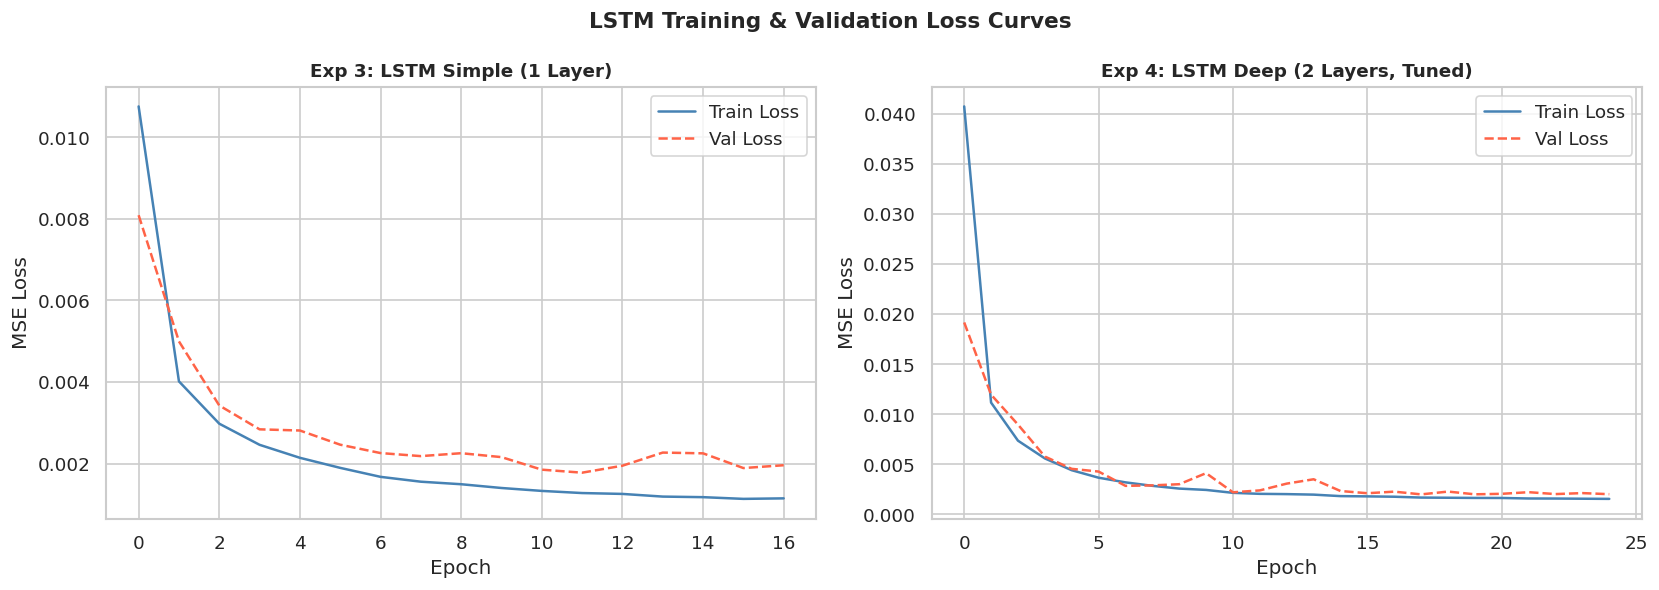

Saved: lstm_training_curves.png


In [28]:
# Plot 1: Training Loss Curves for both LSTMs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in zip(
    axes,
    [history_simple, history_deep],
    ['Exp 3: LSTM Simple (1 Layer)', 'Exp 4: LSTM Deep (2 Layers, Tuned)']
):
    ax.plot(hist.history['loss'],     label='Train Loss', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.suptitle('LSTM Training & Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: lstm_training_curves.png')

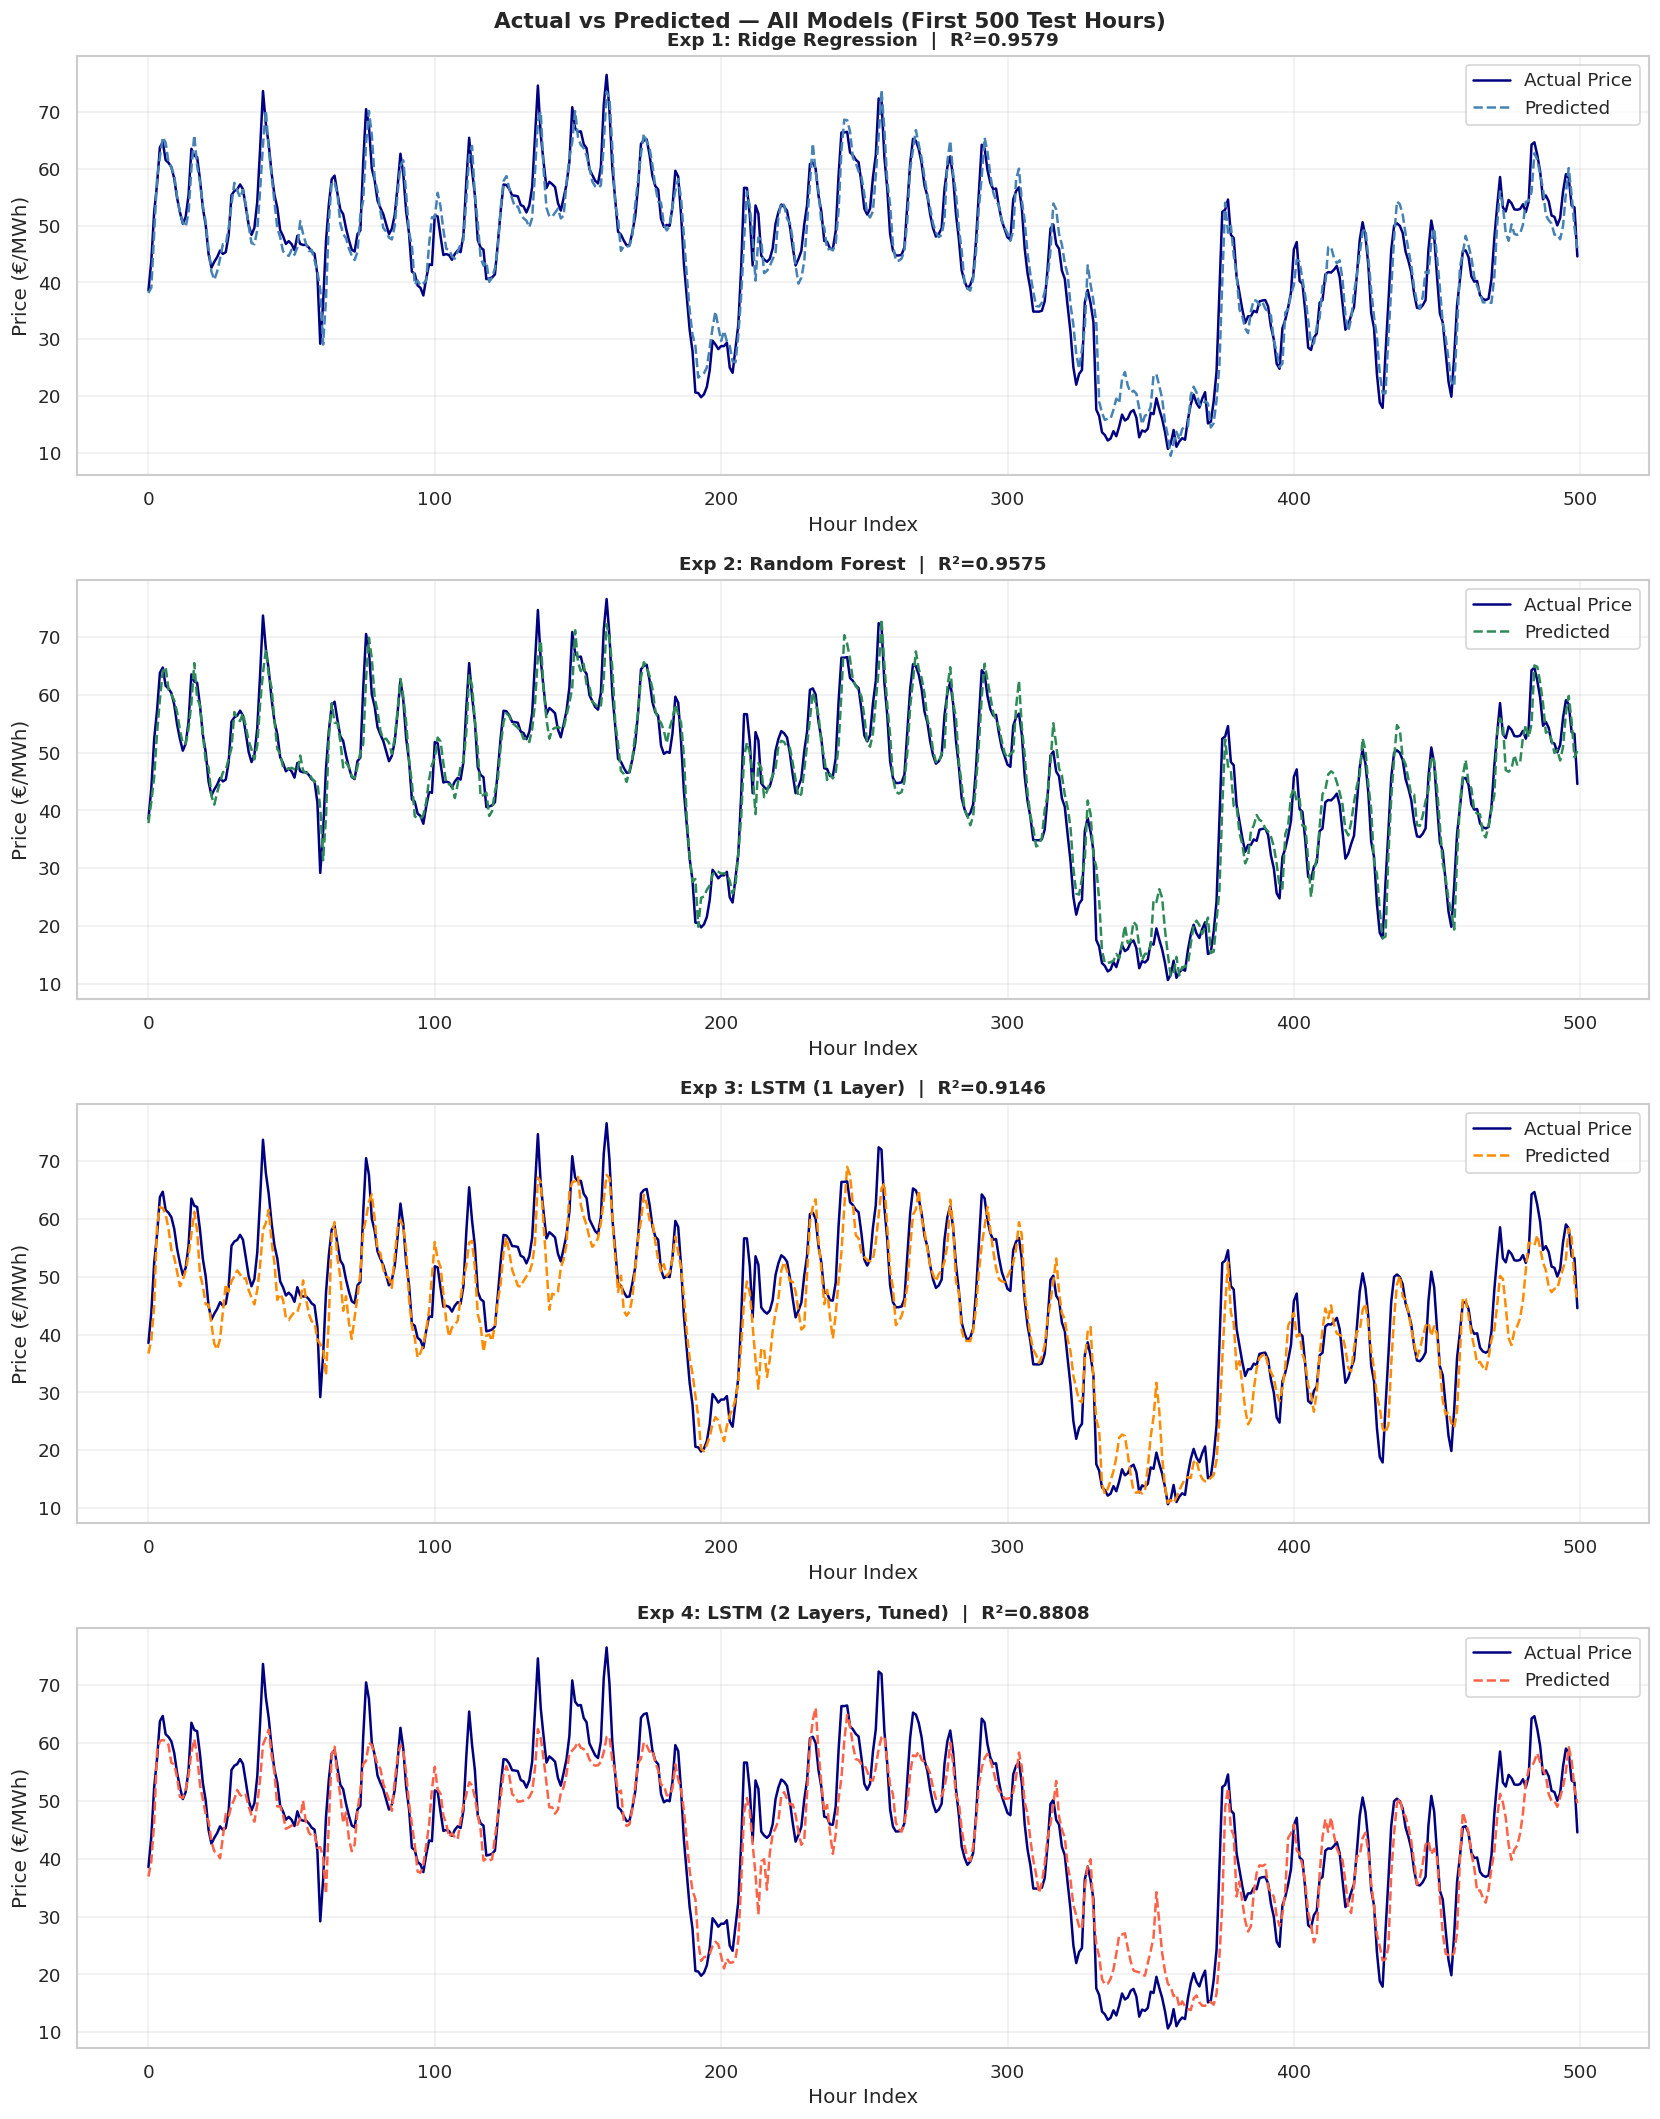

Saved: all_models_predictions.png


In [29]:
# Plot 2: Actual vs Predicted — All 4 Models
n = 500  # show first 500 test hours for clarity

fig, axes = plt.subplots(4, 1, figsize=(14, 18))

predictions = [
    (y_pred_ridge,       y_test,      'Exp 1: Ridge Regression',      'steelblue'),
    (y_pred_rf,          y_test,      'Exp 2: Random Forest',         'seagreen'),
    (y_pred_lstm_simple, y_test_lstm, 'Exp 3: LSTM (1 Layer)',        'darkorange'),
    (y_pred_lstm_deep,   y_test_lstm, 'Exp 4: LSTM (2 Layers, Tuned)','tomato'),
]

for ax, (y_pred, y_true, title, color) in zip(axes, predictions):
    ax.plot(y_true[:n],  label='Actual Price', color='navy',  linewidth=1.5)
    ax.plot(y_pred[:n],  label='Predicted',    color=color,   linewidth=1.5, linestyle='--')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f'{title}  |  R²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (€/MWh)')
    ax.set_xlabel('Hour Index')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted — All Models (First 500 Test Hours)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_predictions.png', bbox_inches='tight')
plt.show()
print('Saved: all_models_predictions.png')

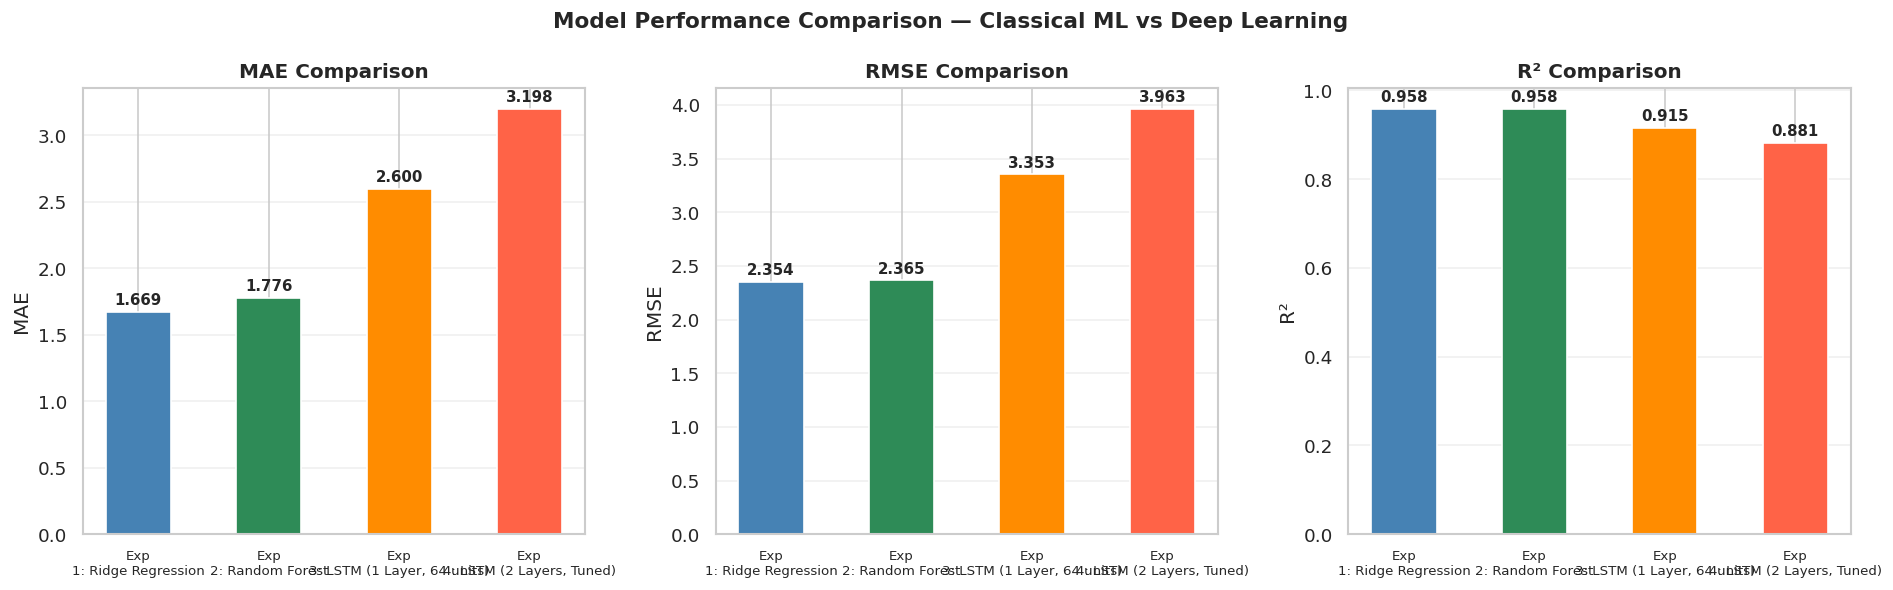

Saved: model_comparison_all.png


In [30]:
# Plot 3: Model Comparison Bar Chart
metrics = ['MAE', 'RMSE', 'R²']
models  = [r['Model'].replace('Exp ', 'Exp\n') for r in results_log]
colors  = ['steelblue', 'seagreen', 'darkorange', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    vals = [r[metric] for r in results_log]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison — Classical ML vs Deep Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight')
plt.show()
print('Saved: model_comparison_all.png')

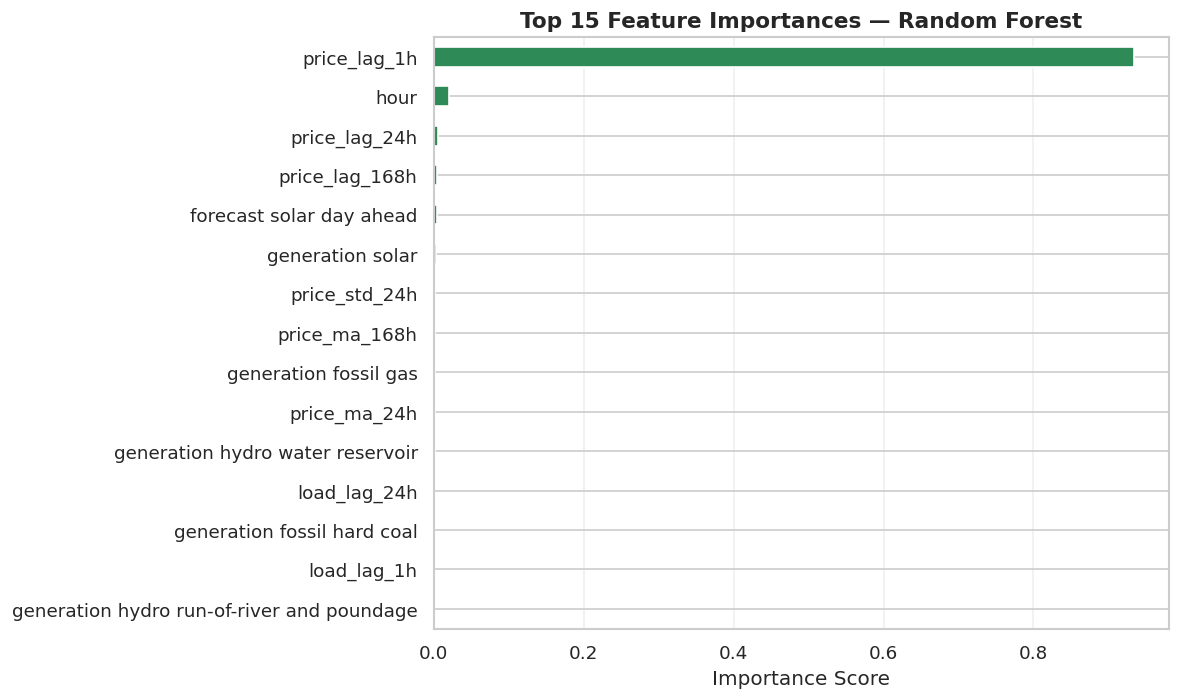

Saved: feature_importance.png


In [31]:
# Plot 4: Feature Importance (Random Forest)
feat_imp = pd.Series(best_rf.feature_importances_, index=FEATURES).nlargest(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='seagreen', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

---
## Save Feature Columns & Final Summary

In [32]:
with open('feature_columns.json', 'w') as f:
    json.dump(FEATURES, f)

print('\n Task 1C Complete!')
print('\n Saved models:')
print('  model_ridge.pkl')
print('  model_random_forest.pkl')
print('  model_lstm_simple.keras')
print('  model_lstm_deep.keras   ← Best model')
print('\n Saved scalers:')
print('  scaler_standard.pkl    (for classical ML)')
print('  scaler_minmax_X.pkl    (for LSTM features)')
print('  scaler_minmax_y.pkl    (for LSTM target)')
print('\n Saved metadata:')
print('  feature_columns.json')
print('\n  Saved plots:')
print('  lstm_training_curves.png')
print('  all_models_predictions.png')
print('  model_comparison_all.png')
print('  feature_importance.png')


 Task 1C Complete!

 Saved models:
  model_ridge.pkl
  model_random_forest.pkl
  model_lstm_simple.keras
  model_lstm_deep.keras   ← Best model

 Saved scalers:
  scaler_standard.pkl    (for classical ML)
  scaler_minmax_X.pkl    (for LSTM features)
  scaler_minmax_y.pkl    (for LSTM target)

 Saved metadata:
  feature_columns.json

  Saved plots:
  lstm_training_curves.png
  all_models_predictions.png
  model_comparison_all.png
  feature_importance.png


In [34]:
import shutil
shutil.copy('model_ridge.pkl', '/content/drive/MyDrive/Pipeline files/model_ridge.pkl')
shutil.copy('model_random_forest.pkl', '/content/drive/MyDrive/Pipeline files/model_random_forest.pkl')
shutil.copy('model_lstm_simple.keras', '/content/drive/MyDrive/Pipeline files/model_lstm_simple.keras')
shutil.copy('model_lstm_deep.keras', '/content/drive/MyDrive/Pipeline files/model_lstm_deep.keras')
shutil.copy('scaler_standard.pkl', '/content/drive/MyDrive/Pipeline files/scaler_standard.pkl')
shutil.copy('scaler_minmax_X.pkl', '/content/drive/MyDrive/Pipeline files/scaler_minmax_X.pkl')
shutil.copy('scaler_minmax_y.pkl', '/content/drive/MyDrive/Pipeline files/scaler_minmax_y.pkl')
shutil.copy('feature_columns.json', '/content/drive/MyDrive/Pipeline files/feature_columns.json')
print('All models saved to Google Drive!')

All models saved to Google Drive!
